In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.shape)
print(df.head())

(42000, 785)
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0      

In [2]:
X = df.drop("label", axis=1)

y = df["label"]

print(X.shape)
print(y.shape)

(42000, 784)
(42000,)


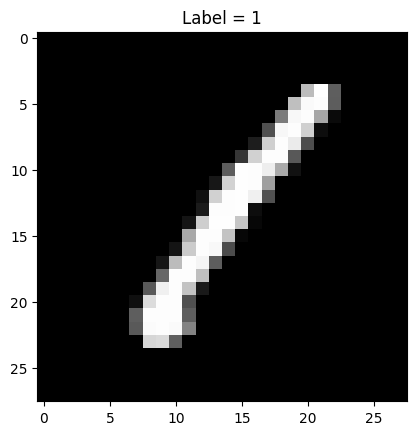

In [3]:
import matplotlib.pyplot as plt

image = X.iloc[0].values.reshape(28,28)

plt.imshow(image, cmap="gray")

plt.title(f"Label = {y.iloc[0]}")

plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
X_train = X_train / 255.0

X_test = X_test / 255.0

In [8]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(784,)
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )

])

In [9]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [10]:
history = model.fit(

    X_train,

    y_train,

    epochs=10,

    batch_size=32,

    validation_split=0.2

)

Epoch 1/10


840/840 [==============================] - 4s 3ms/step - loss: 0.3352 - accuracy: 0.9006 - val_loss: 0.2130 - val_accuracy: 0.9376
Epoch 2/10
840/840 [==============================] - 2s 2ms/step - loss: 0.1454 - accuracy: 0.9535 - val_loss: 0.1373 - val_accuracy: 0.9604
Epoch 3/10
840/840 [==============================] - 1s 2ms/step - loss: 0.0963 - accuracy: 0.9704 - val_loss: 0.1262 - val_accuracy: 0.9647
Epoch 4/10
840/840 [==============================] - 1s 2ms/step - loss: 0.0713 - accuracy: 0.9772 - val_loss: 0.1155 - val_accuracy: 0.9652
Epoch 5/10
840/840 [==============================] - 1s 2ms/step - loss: 0.0511 - accuracy: 0.9831 - val_loss: 0.1310 - val_accuracy: 0.9649
Epoch 6/10
840/840 [==============================] - 1s 2ms/step - loss: 0.0417 - accuracy: 0.9866 - val_loss: 0.1193 - val_accuracy: 0.9686
Epoch 7/10
840/840 [==============================] - 1s 2ms/step - loss: 0.0326 - accuracy: 0.9900 - val_loss: 0.1124 - val_accuracy: 0.9711
Epoc

In [11]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

263/263 [==============================] - 1s 2ms/step - loss: 0.1488 - accuracy: 0.9638
Accuracy: 0.9638095498085022


263/263 [==============================] - 1s 1ms/step


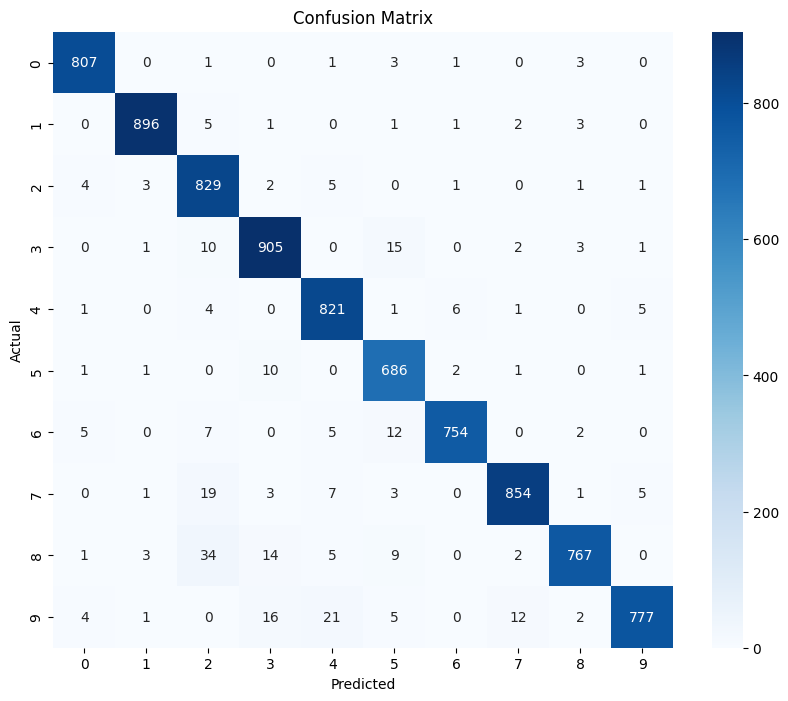

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

263/263 [==============================] - 0s 2ms/step
Total Wrong Predictions: 304


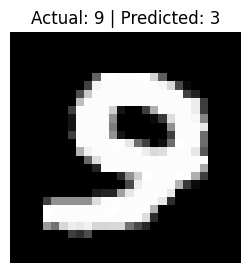

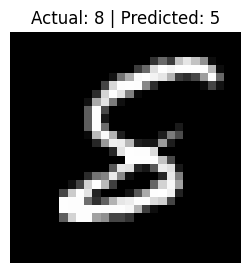

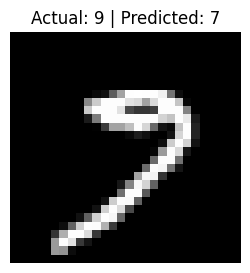

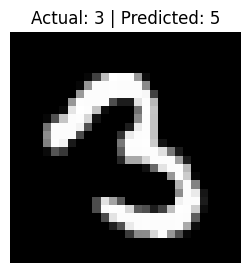

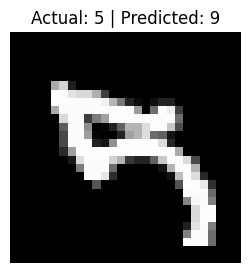

In [ ]:
#Show Wrong Predictions
import numpy as np
import matplotlib.pyplot as plt

predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

wrong_indices = np.where(y_pred != y_test)[0]

print("Total Wrong Predictions:", len(wrong_indices))

for i in range(5):

    idx = wrong_indices[i]

    image = X_test.iloc[idx].values.reshape(28,28)

    plt.figure(figsize=(3,3))

    plt.imshow(image, cmap="gray")

    plt.title(
        f"Actual: {y_test.iloc[idx]} | Predicted: {y_pred[idx]}"
    )

    plt.axis("off")

    plt.show()

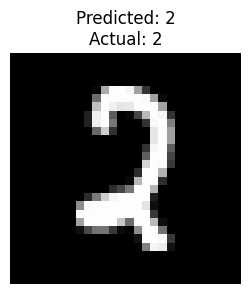

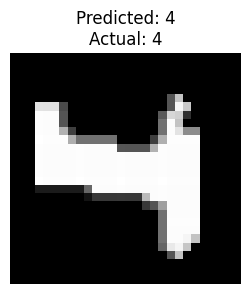

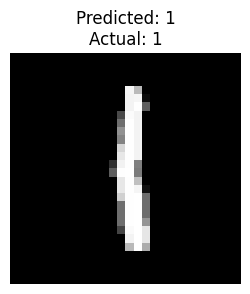

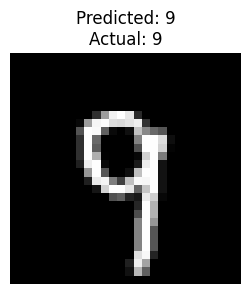

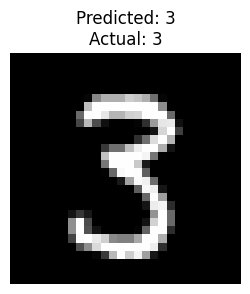

In [ ]:
#Show Random Predictions
import random

for i in range(5):

    idx = random.randint(0, len(X_test)-1)

    image = X_test.iloc[idx].values.reshape(28,28)

    prediction = np.argmax(predictions[idx])

    actual = y_test.iloc[idx]

    plt.figure(figsize=(3,3))

    plt.imshow(image, cmap="gray")

    plt.title(
        f"Predicted: {prediction}\nActual: {actual}"
    )

    plt.axis("off")

    plt.show()

In [ ]:
#Save Model
model.save("mnist_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


c:\Users\Kaviya Sree R.S\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
#Test Loading Saved Model
from tensorflow.keras.models import load_model

loaded_model = load_model("mnist_model.h5")

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
#Predict Using Loaded Model
sample = X_test.iloc[0:1]

prediction = loaded_model.predict(sample)

digit = np.argmax(prediction)

print("Predicted Digit:", digit)
print("Actual Digit:", y_test.iloc[0])

1/1 [==============================] - 0s 85ms/step
Predicted Digit: 8
Actual Digit: 8
